# Exploration et visiualisation des données

Ce notebook est dédié à l'exploration et à la visualisation de  nos deux bases de données : 
 - "Municipal Waste Management Cost Prediction"
 - "Garbage Classification"
 
L'objectif est de comprendre la structure des données, et faire des visualisation afin d'identifier d'éventuelles corrélations.

##  Table des Matières
1. [Librairies et Configuration](#Librairies)
2. [Analyse de la Base de Données : Municipal Waste Management Cost Prediction](#bd1)
3. [Analyse de la Base de Données : Garbage Classification](#bd2)
4. [Synthèse et Conclusion](#conclu)

<a id="Librairies"></a>
## 1. Librairies et Configuration


In [ ]:
import pandas as pd
import random

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import geopandas as gpd

import os


file_path = "../data/public_data_waste_fee.csv"
df = pd.read_csv(file_path)

path_map = "../topoItalie/Reg01012025_g/Reg01012025_g_WGS84.shp"
italie_regions = gpd.read_file(path_map) 

<a id="bd1"></a>
## 2. Analyse de la Base de Données : Municipal Waste Management Cost Prediction

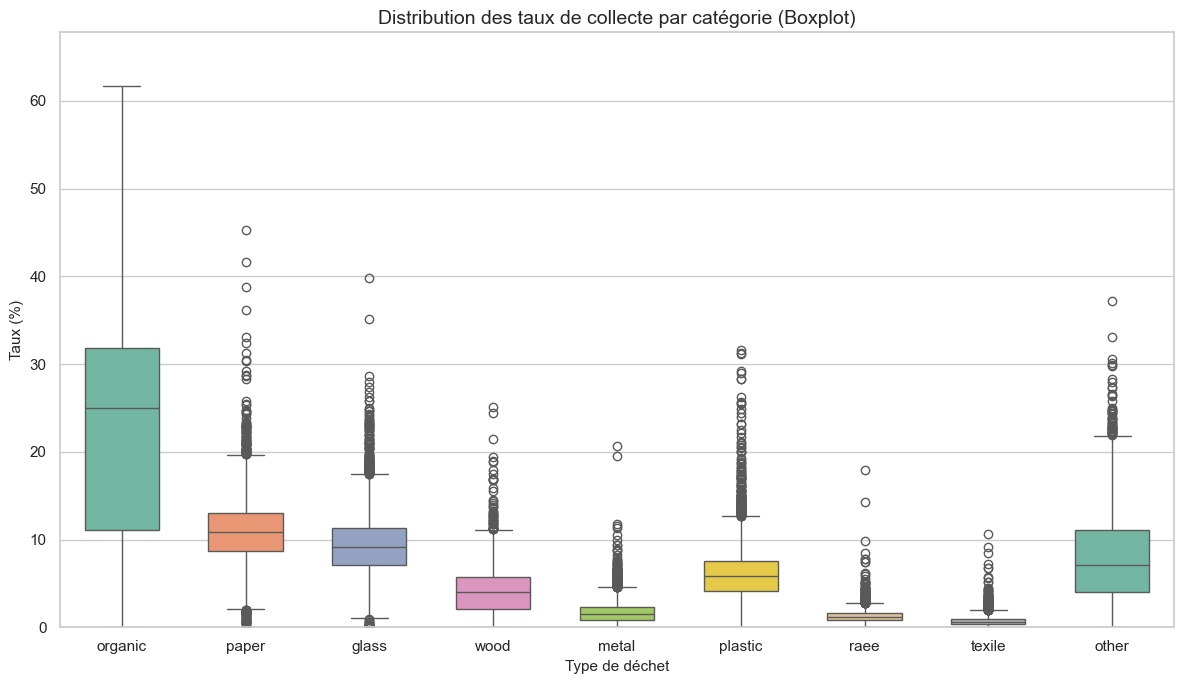

In [ ]:
# Distribution des taux de collecte par catégorie
categories = ['organic', 'paper', 'glass', 'wood', 'metal', 'plastic', 'raee', 'texile', 'other']

for col in categories:
        df[col] = pd.to_numeric(df[col], errors='coerce')

df_long = df.melt(
        value_vars=categories, 
        var_name='Déchet', 
        value_name='Taux_pourcentage'
    )

plt.figure(figsize=(12, 7))
sns.set_theme(style="whitegrid")

sns.boxplot(
        x='Déchet', 
        y='Taux_pourcentage', 
        data=df_long, 
        palette="Set2",
        hue='Déchet',
        legend=False,
        width=0.6 # Ajuste la largeur des boîtes
    )

plt.title('Distribution des taux de collecte par catégorie (Boxplot)', fontsize=14)
plt.xlabel('Type de déchet', fontsize=11)
plt.ylabel('Taux (%)', fontsize=11)
plt.ylim(0, df_long['Taux_pourcentage'].max() * 1.1) # Ajuste l'échelle Y
plt.tight_layout()
plt.show()

Analyse : 
Ce graphique représente le taux de déchets collecté de chaque aux communes en fonction des types de déchets. Les déchets organiques sont les plus collectés mais avec de fortes disparités. Le papier et le verre suivent avec une médiane autour des 10%. À l'inverse, le textile et l'électronique stagnent proche de 2%. Globalement, les déchets organiques sont les plus représentés et le reste des taux reste sous la barre des 10 %. On peut noter également que certaines communes obtiennent des résultats extrêmes bien aux dessus de la moyenne.



---

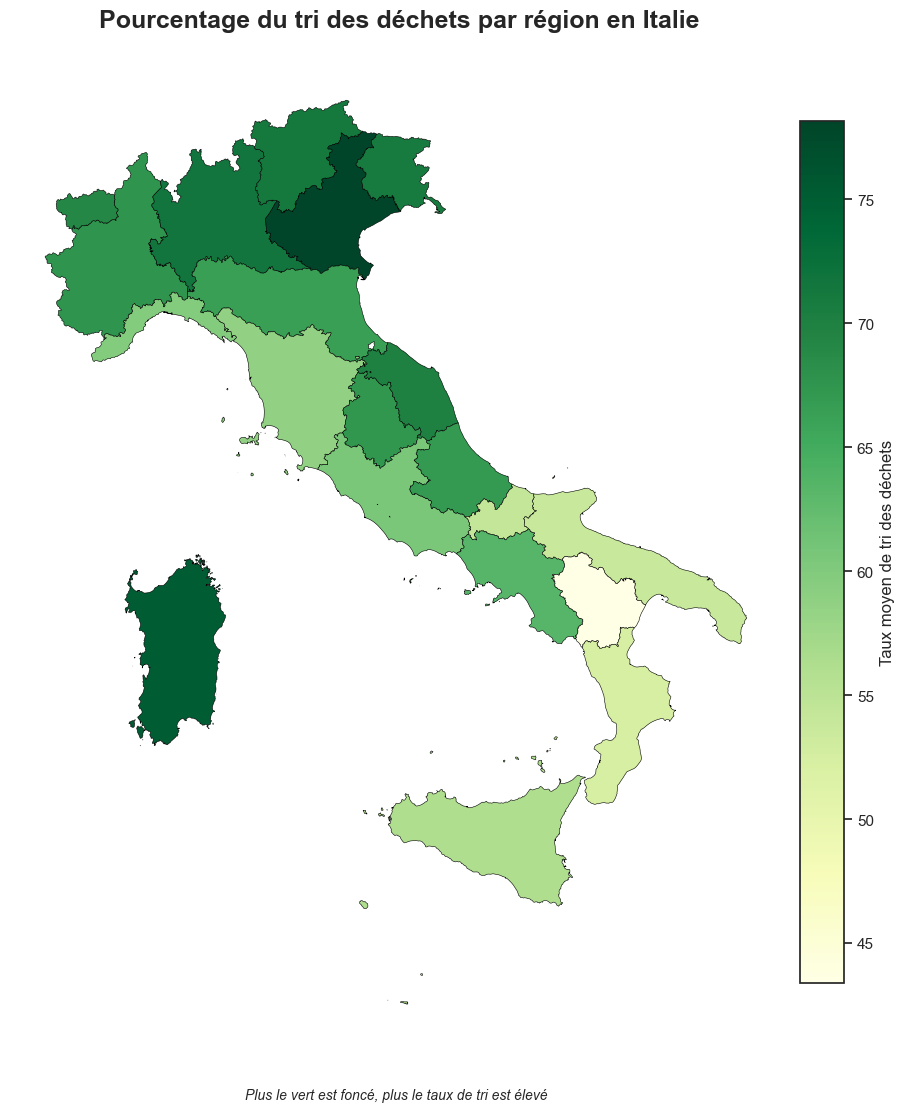

In [ ]:
# Pourcentage du tri des déchets par région en Italie

df_villes = df.copy()

# Note : L'ISTAT utilise des noms bilingues officiels (ex: "Valle d'Aosta/Vallée d'Aoste")
# J'ai ajouté les correspondances pour les régions bilingues et celles qui posaient problème.
mapping = {
    "Valle d'Aosta": "Valle_d'Aosta",
    "Trentino-Alto Adige": "Trentino_Alto_Adige",
    "Friuli-Venezia Giulia": "Friuli_Venezia_Giulia",
    "Emilia-Romagna": "Emilia_Romagna",
    "Piemonte": "piemonte"
}

inv_mapping = {v: k for k, v in mapping.items()}

df_villes['region_clean'] = df_villes['region'].replace(inv_mapping)

stats_regions = df_villes.groupby('region_clean')['sor'].mean().reset_index()

carte_finale = italie_regions.merge(stats_regions, left_on='DEN_REG', right_on='region_clean', how='left')

fig, ax = plt.subplots(figsize=(12, 14))

carte_finale.plot(
    column='sor', 
    ax=ax, 
    legend=True, 
    cmap='YlGn',            # Palette : Yellow (bas) -> Green (haut)
    edgecolor='black', 
    linewidth=0.4,
    missing_kwds={'color': 'lightgrey', 'label': 'Données manquantes'}, 
    legend_kwds={
        'label': "Taux moyen de tri des déchets", 
        'orientation': "vertical", 
        'shrink': 0.8,
        'pad': 0.02
    }
)

plt.title(" Pourcentage du tri des déchets par région en Italie", fontsize=18, fontweight='bold', pad=20)
ax.text(0.5, -0.05, "Plus le vert est foncé, plus le taux de tri est élevé", 
        transform=ax.transAxes, ha="center", fontsize=10, style='italic')
ax.set_axis_off()
plt.show()

Analyse : 
Ici une carte réalisée avec matplotlib (librairie vue pendant le 1er semestre de L3 en Science des Données) représentant le pays de l’Italie ainsi que ses 20 régions délimitées. On obtient une représentation par région du taux de tri des déchets, avec un affichage de plus en plus vert foncé si la ce taux est plus élevé dans la région défini. On peut ainsi remarquer qu’une tendance se dégage, avec un pourcentage de taux plus élevé au fur et à mesure que l’on se dirige au nord du pays, dans les régions plus riches. Cela confirme donc nos pensées du graphique en barres sur le taux de tri par régions. La carte est issue du site de l’Institut National de Statistique italien mettant à jour les frontières chaque année.

---

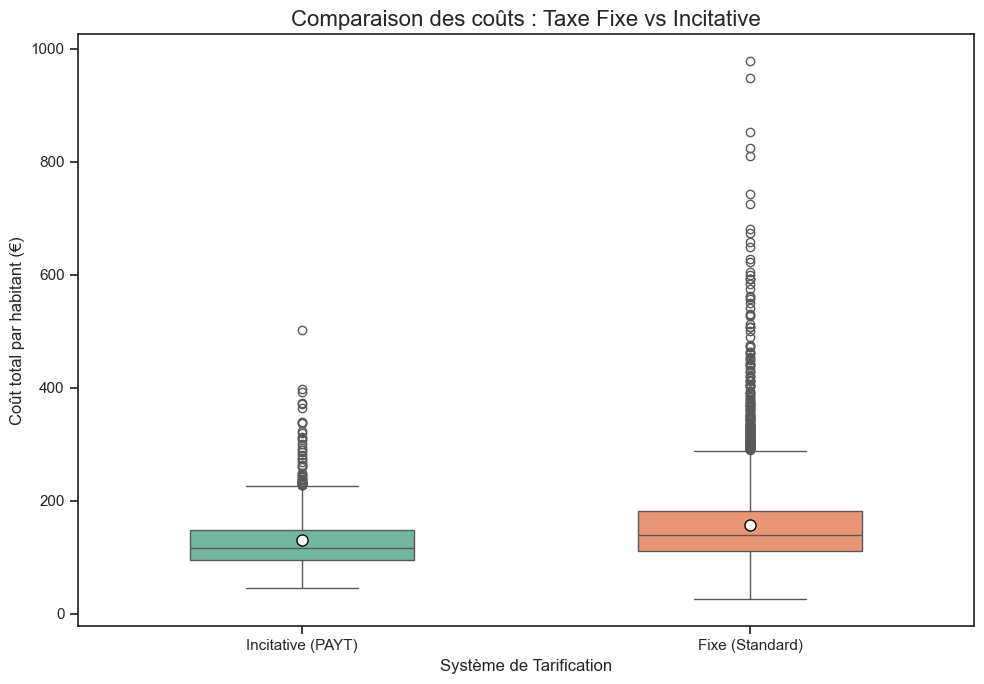

In [8]:
# Comparaison coût : Taxe Fixe vs Incitative

df['type_taxe'] = df['d_fee'].map({0: 'Fixe (Standard)', 1: 'Incitative (PAYT)'})

plt.figure(figsize=(10, 7))
sns.set_theme(style="ticks")

sns.boxplot(
    data=df, 
    x='type_taxe', 
    y='tc', 
    hue='type_taxe',
    palette='Set2',
    legend=False,
    width=0.5,
    showmeans=True,
    meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":"8"}
)

plt.title('Comparaison des coûts : Taxe Fixe vs Incitative', fontsize=16)
plt.xlabel('Système de Tarification', fontsize=12)
plt.ylabel('Coût total par habitant (€)', fontsize=12)
plt.tight_layout()
plt.show()

Analyse : 
On compare la distribution des coûts totaux par habitant (€), selon deux systèmes de taxes des déchets (Initiative (PAYT - Pay As You Throw) et Fixe (Standard)).
La taxe au poids (PAYT) permet de mieux maîtriser les coûts que la taxe fixe. La "boîte" est plus basse, ce qui prouve que le système est efficace pour la majorité des villes. Par contre, les quelques points extrêmes nous montrent que la taxe dépend d’autres variables aussi.

---

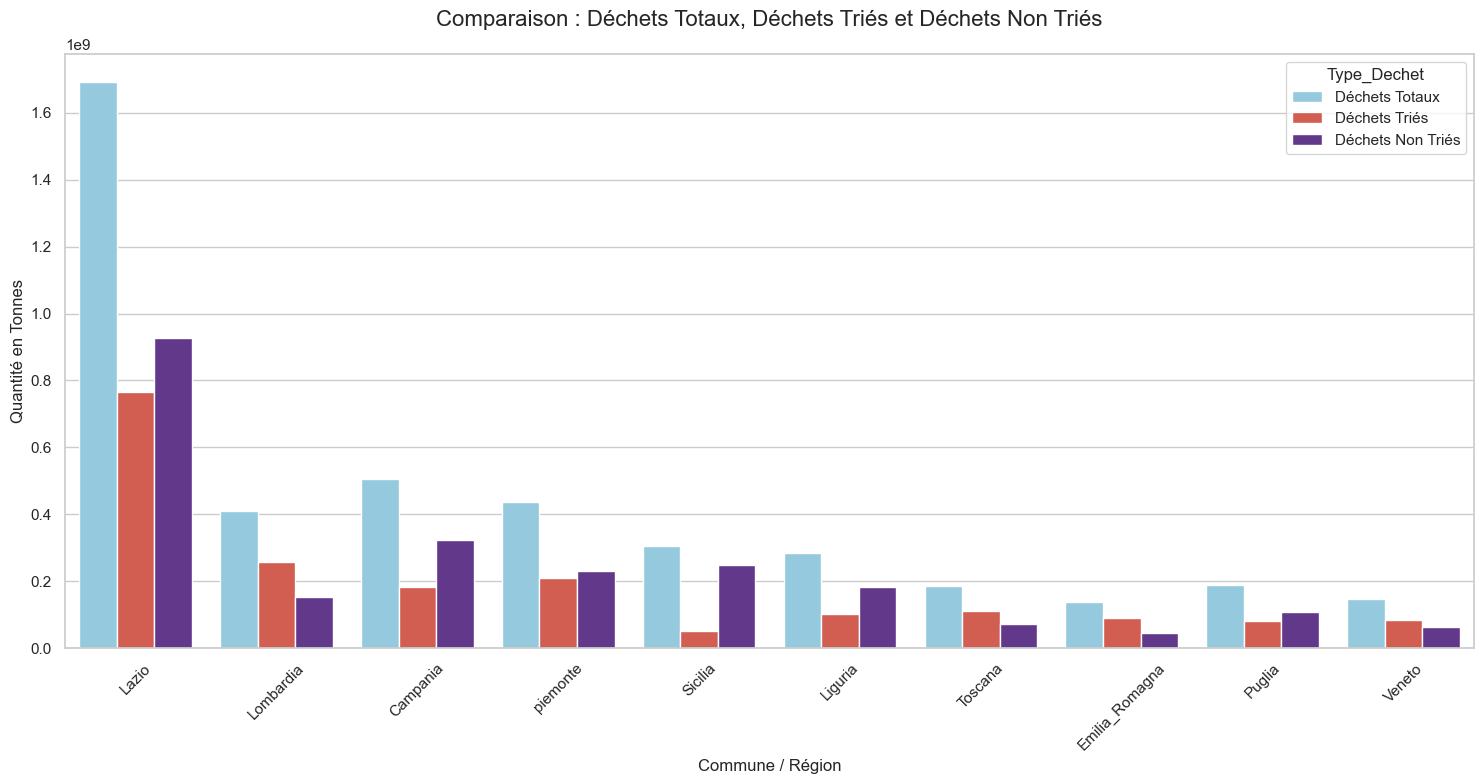

In [ ]:
# Comparaison : Déchets Totaux, Déchets Triés et Déchets Non Triés

df_top = df.nlargest(20, 'msw')

df_plot = df_top.melt(id_vars='region', value_vars=['msw', 'msw_so', 'msw_un'], 
                      var_name='Type_Dechet', value_name='Tonnes')

nom_legende = {
    'msw': 'Déchets Totaux',
    'msw_so': 'Déchets Triés',
    'msw_un': 'Déchets Non Triés'
}
df_plot['Type_Dechet'] = df_plot['Type_Dechet'].map(nom_legende)

plt.figure(figsize=(15, 8))
sns.set_style("whitegrid")

plot = sns.barplot(data=df_plot, x='region', y='Tonnes', hue='Type_Dechet', palette=['skyblue', '#e74c3c', "#622a99"], errorbar=None)

plt.title('Comparaison : Déchets Totaux, Déchets Triés et Déchets Non Triés', fontsize=16, pad=20)
plt.xlabel('Commune / Région', fontsize=12)
plt.ylabel('Quantité en Tonnes', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Analyse : 
Ce graphique nous permet de comparer les 20 villes les plus productrices de déchets (ayant la variable “msw” la plus élevée). Les villes ont été regroupées par régions. On observe que la Lazio est la région qui produit le plus de déchets, avec environ 1.7 milliard de tonnes. Une part importante de ces déchets est encore non triée, cela peut s’expliquer par le fait que Rome, la capitale, est dans la région de Lazio. Rome est la ville la plus peuplée d’Italie, et il y a beaucoup de tourisme dans cette ville. D’autres régions ont cependant une part plus importante de déchets triés comme Lombardia, Toscana, Emilia-Romagna et Veneto.

---

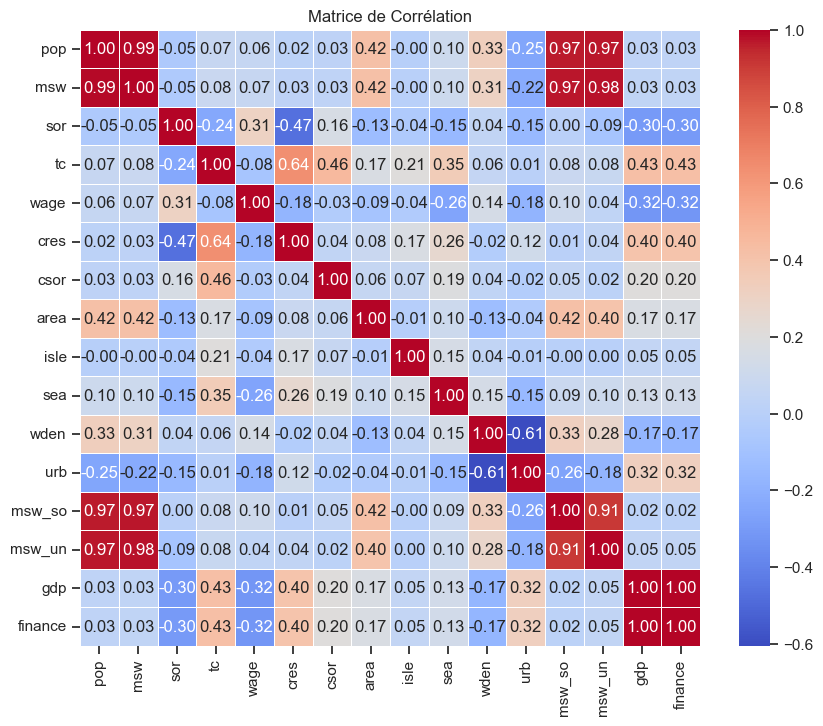

In [7]:
# Matrice de corrélation

data_corr = df[['pop', 'msw', 'sor', 'tc', 'wage', 'cres', 'csor', 'area', 'isle', 'sea', 'wden', 'urb', 'msw_so','msw_un', 'gdp', 'finance']]

matrix = data_corr.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matrice de Corrélation')
plt.show()

Analyse : 
Notre matrice de corrélation révèle que le volume total de déchets (msw) et le coût de gestion (tc) sont quasi-parfaitement corrélés à la population, mais que la véritable performance se mesure au taux de tri (sor). On observe une fracture nette selon le mode de tarification : les communes utilisant la taxe au poids (PAYT) affichent systématiquement des taux de recyclage supérieurs aux communes sous taxe STANDARD, prouvant que l'incitation financière surpasse la simple sensibilisation. Aussi, la morphologie urbaine joue un rôle clé : les zones à forte densité (wden et urb élevés) peinent davantage à trier efficacement, probablement à cause des contraintes logistiques de l'habitat collectif. Enfin, l'analyse financière suggère que le coût total est souvent alourdi par les déchets non triés (msw_un), confirmant que le recyclage n'est pas seulement un impératif écologique, mais aussi une stratégie de réduction des coûts municipaux à long terme.

---

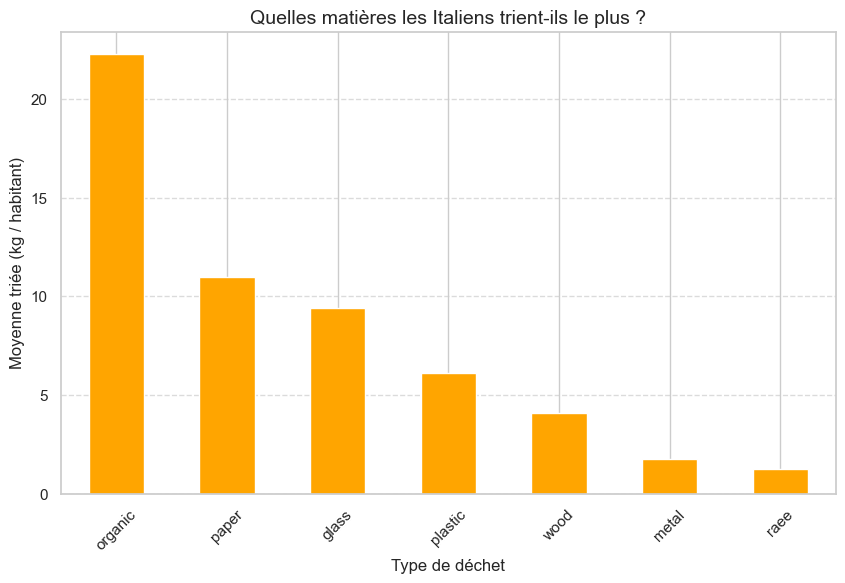

In [8]:
# Matières les plus triées par les Italiens

materials = ['organic', 'paper', 'glass', 'wood', 'metal', 'plastic', 'raee']

# On calcule la moyenne pour chaque matière (en ignorant les cases vides)
mean_tri = df[materials].mean().sort_values(ascending=False)

# Création du graphique
plt.figure(figsize=(10, 6))
mean_tri.plot(kind='bar', color='orange')

plt.title('Quelles matières les Italiens trient-ils le plus ?', fontsize=14)
plt.ylabel('Moyenne triée (kg / habitant)')
plt.xlabel('Type de déchet')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Analyse :
On compare la moyenne de chaque matériau pour voir ce que les gens mettent le plus dans les bacs de recyclage.
Ce qu'on remarque tout de suite avec ce graphique, c'est que le tri n'est pas du tout équilibré entre les matériaux : c'est l'organique qui gagne haut la main. Comme c'est la matière la plus lourde, c’est elle qui fait monter les scores de recyclage. Le papier et le verre suivent loin derrière, tandis que le plastique semble faible alors qu'il prend beaucoup de place : c’est simplement parce qu’il est très léger en poids. En conclusion, l’analyse montre que le tri n’est pas qu’une question de bonne volonté, c’est une question de poids.

---

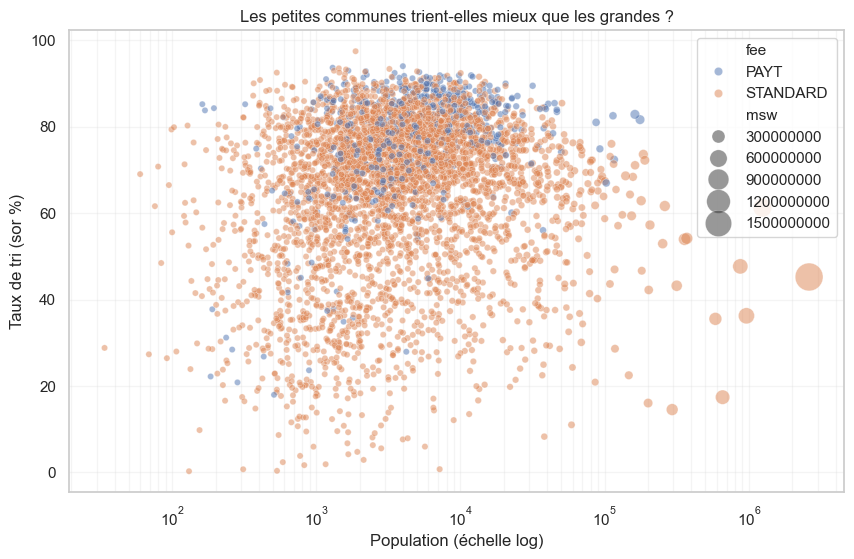

r


In [ ]:
# Comparaison petite commune VS grande commune

plt.figure(figsize=(10, 6))
#On utilise une échelle log pour la population car les écarts sont énormes
sns.scatterplot(data=df, x='pop', y='sor', size='msw', hue='fee', alpha=0.5, sizes=(20, 400))
plt.xscale('log')
plt.title('Les petites communes trient-elles mieux que les grandes ?')
plt.xlabel('Population (échelle log)')
plt.ylabel('Taux de tri (sor %)')
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.show()

Analyse : 
Ce graphique est appelé ”Bubble Chart”, il croise la taille de la population, le taux de recyclage, le volume total de déchets et le mode de facturation. Il sert de représentation des déchets par commune en croisant, leur taille et leur mode de facturation, il nous permet de visualiser instantanément l’efficacité du recyclage à l’échelle d’un territoire. Malgré un nombre moins élevé, il y a une tendance montrant que les communes utilisant la taxe au poids (PAYT) affichent un meilleur taux de tri de déchets plus élevé que la taxe (STANDARD). Enfin, les villes les plus peuplées, celles représentées à droite, ont tendance à avoir un taux de tri plus bas, montrant la difficulté d’avoir un système de tri efficace à grande échelle. 

---

--- Taux de tri moyen par tranche d'alt ---
classe_alt
0-250m      69.846979
250-750m    63.660454
+750m       55.950845
Name: sor, dtype: float64


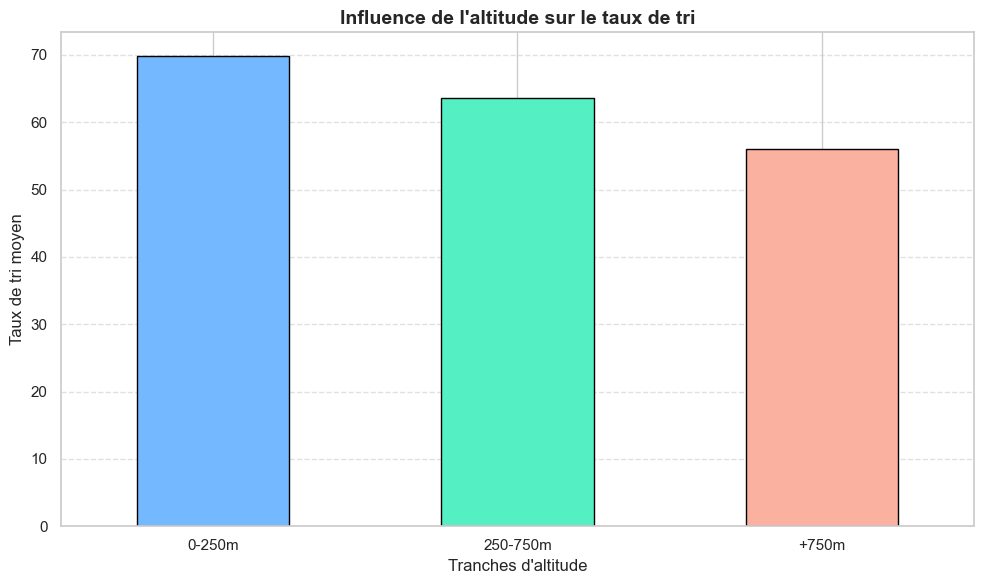

In [ ]:
# Incluence de l'altitude sur le tri

df['alt'] = pd.to_numeric(df['alt'], errors='coerce')
df['sor'] = pd.to_numeric(df['sor'], errors='coerce')
df = df.dropna(subset=['alt', 'sor'])

bins = [0, 250, 750, df['alt'].max()]
labels = ['0-250m', '250-750m', '+750m']
df['classe_alt'] = pd.cut(df['alt'], bins=bins, labels=labels)

analyse = df.groupby('classe_alt')['sor'].mean()

#print("--- Taux de tri moyen par tranche d'alt ---")
#print(analyse)

plt.figure(figsize=(10, 6))
analyse.plot(kind='bar', color=['#74b9ff', '#55efc4', '#fab1a0'], edgecolor='black')
plt.title('Influence de l\'altitude sur le taux de tri', fontsize=14, fontweight='bold')
plt.xlabel('Tranches d\'altitude', fontsize=12)
plt.ylabel('Taux de tri moyen', fontsize=12)
plt.xticks(rotation=0) 
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Analyse : 
Ce graphique en barre étudie une possible corrélation entre l’altitude des communes et leurs efficacités en termes de tri. Tout d’abord les communes ont été classées selon leurs altitudes en 3 catégories: - de 250 m, 250-750 m et + de 750 m. Une fois cela fait, on calcule pour chacune de ces catégories, la moyenne en % du taux de déchets triés. On peut supposer une corrélation donc entre ces deux facteurs : le taux de tri diminue à mesure que l’altitude augmente. De 0 à 250 m, le taux moyen atteint les 70% tandis qu’en montagne, le taux n’atteint “seulement” 56%. Cette tendance peut s’expliquer par plusieurs facteurs logistiques propres aux zones de haute altitude comme l’accessibilité (collecte plus complexe et coûteuse dans zones montagneuses, accès difficile pour les camion de ramassage), les infrastructures de tri (centres de tri et déchetteries situées plus loin des villages de hautes montagnes que des villes de plaine) où encore la saisonnalité (zones touristiques de montagnes subissent des pics de fréquentation saisonnière qui rend la gestion des déchets plus difficile).

<a id="bd2"></a>

## 2. Analyse de la Base de Données : Garbage Classification

Le graphique suivant nous permet d’avoir un aperçu sur la structure de notre jeu de données d’images « Garbage Classification ». Le nombre d’images par catégorie est strictement proportionnel entre les dossiers de d’entrainement, de validation et de test. Cependant, à l’intérieur de ces dossiers, il y a des disparités entre chaque classe de déchets ( 594 pour le  « paper » contre 137 pour « trash »). Ce cas, plus réaliste, nous obligera à ne pas nous fier uniquement à l’Accuracy mais à d’autres éléments tels que le F1-Score ou encore une matrice de confusion et permettra de rendre notre système le plus performant et robuste possible sur l’ensemble des catégories. 

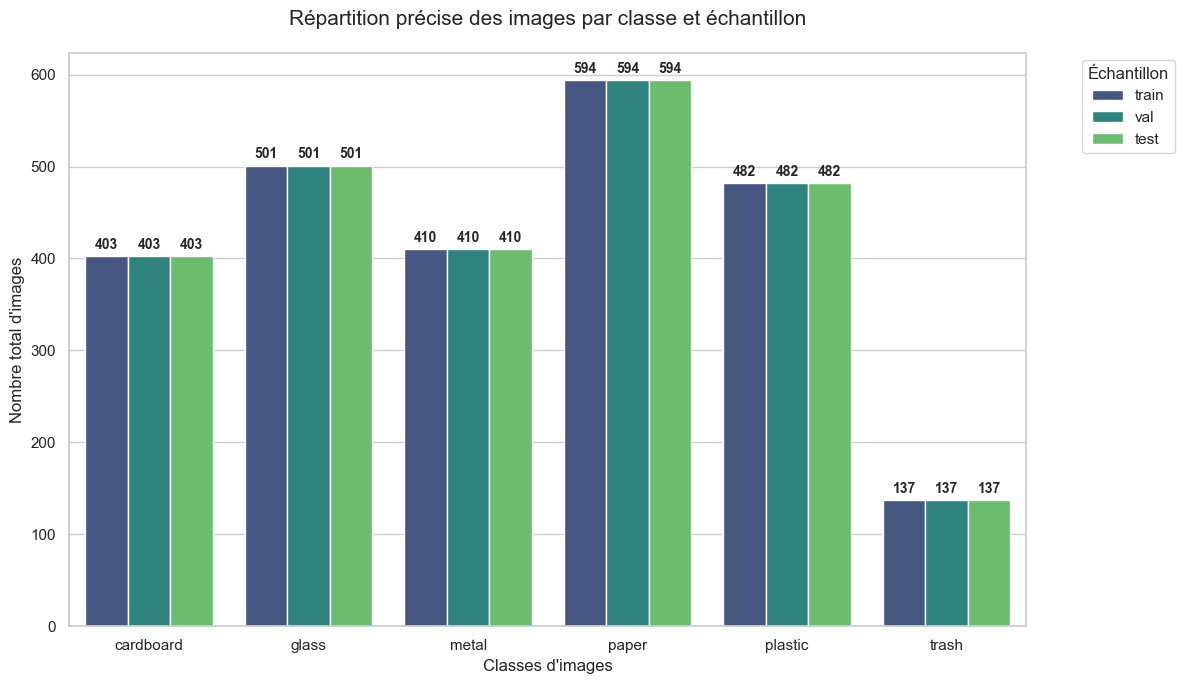

In [ ]:
base_dir = '../data'
splits = ['train', 'val', 'test']
stats = []

for split in splits:
    split_path = os.path.join(base_dir, split)
    if os.path.exists(split_path):
        categories = [d for d in os.listdir(split_path) if os.path.isdir(os.path.join(split_path, d))]
        for cat in categories:
            n_images = len(os.listdir(os.path.join(split_path, cat)))
            stats.append({'Split': split, 'Catégorie': cat, 'Nombre': n_images})

df_all_stats = pd.DataFrame(stats)

plt.figure(figsize=(12, 7))
sns.set_theme(style="whitegrid")

ax = sns.barplot(data=df_all_stats, x='Catégorie', y='Nombre', hue='Split', palette='viridis')

for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=10, fontweight='bold')

plt.title('Répartition précise des images par classe et échantillon', fontsize=15, pad=20)
plt.xlabel('Classes d\'images', fontsize=12)
plt.ylabel('Nombre total d\'images', fontsize=12)
plt.legend(title='Échantillon', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

---

Afin d'optimiser la phase d'entraînement, nous avons veillé à ce que l'ensemble des images possède une résolution uniforme (384x512). Cette uniformisation nous permet d'éviter de nombreuses étapes lourdes comme le redimensionnement ou le recadrage qui pourraient affecter les caractéristiques des objets à détecter. Voici un échantillons des images présente dans notre base de données.

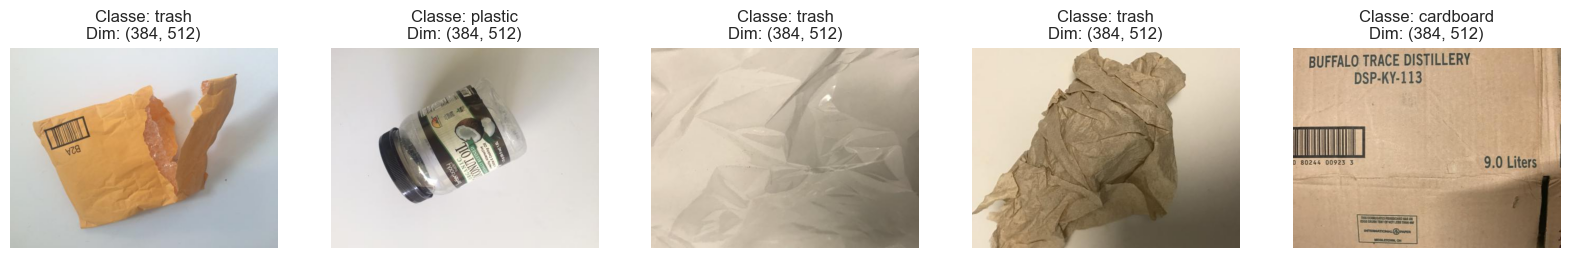

In [4]:
base_path = "../data/train"
categories = os.listdir(base_path)
n=5
plt.figure(figsize=(20, 10))
    
for i in range(n):
        cat = random.choice(categories)
        img_name = random.choice(os.listdir(os.path.join(base_path, cat)))
        img_path = os.path.join(base_path, cat, img_name)
        
        img = mpimg.imread(img_path)
        plt.subplot(1, n, i+1)
        plt.imshow(img)
        plt.title(f"Classe: {cat}\nDim: {img.shape[:2]}")
        plt.axis('off')


<a id="conclu"></a>
## 3. Synthèse et Conclusion


....